# Deteção de Cyberbullying com Processamento de Linguagem Natural (NLP)

Este projeto tem como objetivo desenvolver um modelo de *Machine Learning* capaz de classificar textos (perguntas e respostas retiradas da rede social Formspring) e identificar se contêm linguagem associada a Cyber-Bullying.

O fluxo de trabalho deste projeto de Processamento de Linguagem Natural (NLP) inclui:
1. **Análise Exploratória e Limpeza de Texto:** Remoção de pontuação, *stop words* (palavras comuns sem valor semântico) e aplicação de *Stemming* (redução das palavras à sua raiz).
2. **Vetorização (TF-IDF):** Conversão do texto limpo em matrizes numéricas, avaliando a importância de cada palavra no contexto do documento.
3. **Modelação e Avaliação:** Treino de modelos de classificação e avaliação de métricas (Accuracy, F1-Score) para lidar com eventuais desequilíbrios nos dados.

In [2]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

# Bibliotecas específicas para NLP (Natural Language Processing)
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Fazer o download do dicionário de 'stop words' do NLTK (executar apenas uma vez)
nltk.download('stopwords', quiet=True)

# Configuração visual para os gráficos
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento e Análise Inicial dos Dados
Vamos carregar o conjunto de dados e verificar a sua estrutura. É crucial perceber a distribuição da nossa variável alvo (`answer`), que indica se o texto é considerado *bullying* (Yes) ou não (No).

,text,answer
0,Q: what&#039;s your favorite song? :D<br>A: I ...,No
1,Q: <3<br>A: </3 ? haha jk! <33,No
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,No
3,Q: (:<br>A: ;(,No
4,Q: ******************MEOWWW*******************...,No


Dimensão do dataset: 14147 linhas e 2 colunas.
Valores nulos: \ntext      0
answer    0
dtype: int64\n


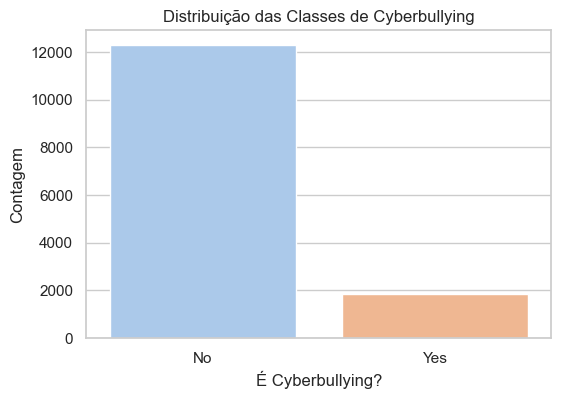

Distribuição em percentagem:
answer
No     86.908885
Yes    13.091115
Name: proportion, dtype: float64


In [3]:
# Carregar o dataset
df = pd.read_csv('Formspring_augmented.csv')

display(df.head())

# Verificar dimensão e valores nulos
print(f"Dimensão do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print(f"Valores nulos: \\n{df.isnull().sum()}\\n")

# Visualizar a distribuição das classes (Bullying vs Não Bullying)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='answer', palette='pastel')
plt.title('Distribuição das Classes de Cyberbullying')
plt.xlabel('É Cyberbullying?')
plt.ylabel('Contagem')
plt.show()

# Percentagem exata
print("Distribuição em percentagem:")
print(df['answer'].value_counts(normalize=True) * 100)

*Insights da Análise Inicial:*
Como podemos observar, existe um enorme desequilíbrio de classes (*class imbalance*). A esmagadora maioria dos textos não é *cyberbullying*. Isto significa que, mais à frente, a métrica de *Accuracy* (precisão global) poderá ser enganadora, pelo que teremos de olhar atentamente para o *F1-Score*.

## 2. Limpeza e Pré-processamento de Texto
O texto bruto está cheio de "ruído" (pontuação, tags HTML como `<br>`, maiúsculas/minúsculas). Vamos criar uma função profissional para limpar cada linha de texto e extrair apenas o "sumo" semântico.

In [ ]:
# Inicializar o stemmer para inglês e a lista de stop words
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words("english"))

def limpar_texto(texto):
    if not isinstance(texto, str):
        return ""
    
    # 1. Converter para minúsculas
    texto = texto.lower()
    
    # 2. Remover tags HTML (ex: <br>) e caracteres especiais
    texto = re.sub(r'<.*?>', ' ', texto)
    
    # 3. Remover pontuação e números
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    texto = re.sub(r'\\d+', '', texto)
    
    # 4. Remover stop words e aplicar stemming (cortar os sufixos das palavras)
    palavras = texto.split()
    palavras_limpas = [stemmer.stem(p) for p in palavras if p not in stop_words]
    
    return " ".join(palavras_limpas)

# Aplicar a função ao nosso dataset e criar uma nova coluna
print("A limpar o texto. Isto pode demorar alguns segundos...")
df['texto_limpo'] = df['text'].apply(limpar_texto)

# Converter a nossa variável alvo ('answer') para 1 (Yes) e 0 (No)
df['label'] = df['answer'].map({'Yes': 1, 'No': 0})

# Mostrar a comparação entre o texto original e o texto limpo
display(df[['text', 'texto_limpo', 'label']].head())

A limpar o texto. Isto pode demorar alguns segundos...


,text,texto_limpo,label
0,Q: what&#039;s your favorite song? :D<br>A: I ...,q what039 favorit song like mani song favorit,0
1,Q: <3<br>A: </3 ? haha jk! <33,q 3 haha jk 33,0
2,Q: &quot;hey angel you duh sexy&quot;<br>A: R...,q quothey angel duh sexyquot realli thank haha,0
3,Q: (:<br>A: ;(,q,0
4,Q: ******************MEOWWW*******************...,q meowww rawr,0


## 3. Vetorização de Texto (TF-IDF)
Os algoritmos de *Machine Learning* não conseguem ler palavras, apenas números. Para resolver isto, vamos usar a técnica **TF-IDF (Term Frequency - Inverse Document Frequency)**.

Em vez de apenas contar quantas vezes uma palavra aparece (o que daria demasiada importância a palavras comuns), o TF-IDF dá mais "peso" a palavras que aparecem muito num texto específico, mas raramente nos outros textos. Isto é perfeito para destacar insultos ou palavras-chave de *bullying*.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("A iniciar a vetorização do texto...")

# Inicializar o TfidfVectorizer
# max_features=5000: Limita o vocabulário às 5000 palavras mais importantes (evita ruído e lentidão)
# ngram_range=(1, 2): Analisa palavras individuais e também pares de palavras (ex: "you ugly")
vetorizador = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Ajustar e transformar o texto limpo numa matriz de números (X)
X = vetorizador.fit_transform(df['texto_limpo'])

# A nossa variável alvo continua a ser a coluna 'label' (y)
y = df['label']

print(f"Formato da matriz de texto (Documentos, Palavras): {X.shape}")

# Dividir os dados em Treino (80%) e Teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Nota: 'stratify=y' garante que a proporção de bullying/não-bullying se mantém igual no treino e no teste.

A iniciar a vetorização do texto...
Formato da matriz de texto (Documentos, Palavras): (14147, 5000)


## 4. Modelação: Classificação de Texto
Com a matriz matemática pronta, vamos treinar diferentes modelos e comparar a sua eficácia. Em NLP, o algoritmo **Naive Bayes** é um clássico devido à sua excelente capacidade de lidar com probabilidades de palavras. Vamos testá-lo lado a lado com a Regressão Logística, a Árvore de Decisão e o poderoso Random Forest.

In [6]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dicionário de modelos para testar
modelos = {
    "Naive Bayes": MultinomialNB(),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

resultados = []

print("A treinar os modelos de NLP. Aguarde...")

for nome, modelo in modelos.items():
    # Treinar o modelo
    modelo.fit(X_treino, y_treino)
    
    # Gerar previsões
    previsoes = modelo.predict(X_teste)
    
    # Calcular métricas
    acc = accuracy_score(y_teste, previsoes)
    prec = precision_score(y_teste, previsoes)
    rec = recall_score(y_teste, previsoes)
    f1 = f1_score(y_teste, previsoes)
    
    resultados.append({
        "Modelo": nome, 
        "Accuracy": acc, 
        "Precision": prec, 
        "Recall": rec, 
        "F1-Score": f1
    })

# Visualizar resultados numa tabela colorida
df_resultados = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False)
display(df_resultados.style.background_gradient(cmap='Purples'))

A treinar os modelos de NLP. Aguarde...


,Modelo,Accuracy,Precision,Recall,F1-Score
1,Regressão Logística,0.953710,0.968627,0.667568,0.790400
3,Random Forest,0.951943,0.923913,0.689189,0.789474
0,Naive Bayes,0.947350,0.982533,0.608108,0.751252
2,Decision Tree,0.928622,0.718750,0.745946,0.732095


## 5. Avaliação do Modelo e Matriz de Confusão
Em problemas de deteção de comportamentos nocivos (onde a classe positiva é minoritária), o **Recall** (a capacidade de apanhar os casos de *bullying* sem deixar escapar nenhum) e o **F1-Score** são muito mais importantes que a *Accuracy* global.

Vamos avaliar onde o nosso melhor modelo (que nestes casos costuma ser o *Random Forest* ou a *Regressão Logística*) comete erros.

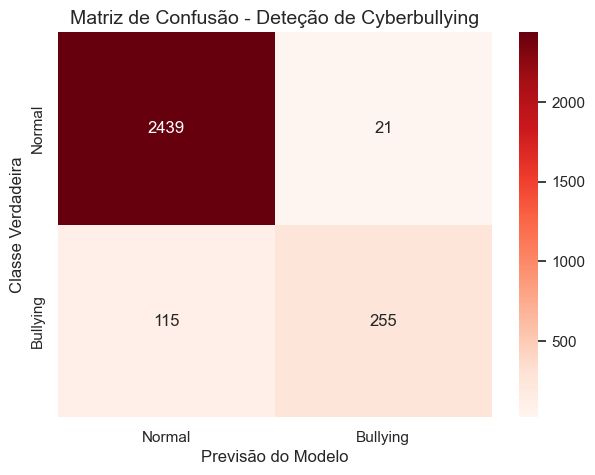

\nTeste prático com a frase: 'you are so ugly and I hate you, go away'
Resultado do Modelo: Bullying Detetado 🚨


In [7]:
from sklearn.metrics import confusion_matrix

# Selecionar o melhor modelo (ex: Random Forest)
melhor_modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
melhor_modelo.fit(X_treino, y_treino)
previsoes_finais = melhor_modelo.predict(X_teste)

# Gerar Matriz de Confusão
cm = confusion_matrix(y_teste, previsoes_finais)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Normal', 'Bullying'], 
            yticklabels=['Normal', 'Bullying'])
plt.title('Matriz de Confusão - Deteção de Cyberbullying', fontsize=14)
plt.ylabel('Classe Verdadeira', fontsize=12)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.show()

# Testar com uma frase inventada agora!
frase_teste = ["you are so ugly and I hate you, go away"]
frase_limpa = [limpar_texto(frase_teste[0])]
vetor_teste = vetorizador.transform(frase_limpa)

previsao_teste = melhor_modelo.predict(vetor_teste)
resultado_texto = "Bullying Detetado 🚨" if previsao_teste[0] == 1 else "Comentário Normal ✅"

print(f"\\nTeste prático com a frase: '{frase_teste[0]}'")
print(f"Resultado do Modelo: {resultado_texto}")